## tl;dr

The preregistered restricted backtest does not support adding a static external-context weight to V3. Small event and sector weights improved calibration but did not preserve non-negative lift in both later reused windows. Global risk reduction was period-dependent rather than stable.

## Context & Methods

This notebook reads the immutable result produced from the frozen August 18 preregistration. It does not refit parameters or access the network. All historical outcomes have been viewed before, so findings are exploratory mechanism evidence only.

### Key Assumptions

- The retained opportunity-candidate pool is not the full production V3 universe.
- Effective-dated SW2021 membership is used provisionally; historical vendor first-seen and revision lineage are unavailable.
- Five-day outcomes overlap, so uncertainty uses a five-trading-day moving-block bootstrap.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt

RESULT_PATH = Path('../../../data/research_validation_forward_20260808/external/restricted-external-context-backtest-20260818-v2.json')
result = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
material = {key: value for key, value in result.items() if key != 'content_digest'}
rendered = json.dumps(material, ensure_ascii=False, sort_keys=True, separators=(',', ':'), default=str)
assert hashlib.sha256(rendered.encode('utf-8')).hexdigest() == result['content_digest']
result['content_digest']

Matplotlib is building the font cache; this may take a moment.


'9bdd802611099a42224bac8bf8cc1ee2b0008ce6fed428a839929e963fe38e58'

## Data

The analysis joins exact registered V3 core scores, retained five-day candidate outcomes, Tushare structured earnings events, effective-dated SW2021 memberships and sector closes, plus four global equity indices.

In [2]:
quality = result['data_quality']
coverage = {
    'joined_rows': quality['join']['joined_row_count'],
    'signal_days': quality['rows']['distinct_signal_days'],
    'event_coverage': quality['rows']['event_present_rows'] / quality['join']['joined_row_count'],
    'sector_coverage': quality['rows']['sector_present_rows'] / quality['join']['joined_row_count'],
    'global_coverage': quality['rows']['global_present_rows'] / quality['join']['joined_row_count'],
}
coverage

{'joined_rows': 10267,
 'signal_days': 648,
 'event_coverage': 0.18759131197039058,
 'sector_coverage': 0.9988312067790007,
 'global_coverage': 1.0}

## Results

The chart compares the preregistered selected weight for each arm against the unchanged lambda-zero baseline. Values are mean five-day Top3 return lift in basis points.

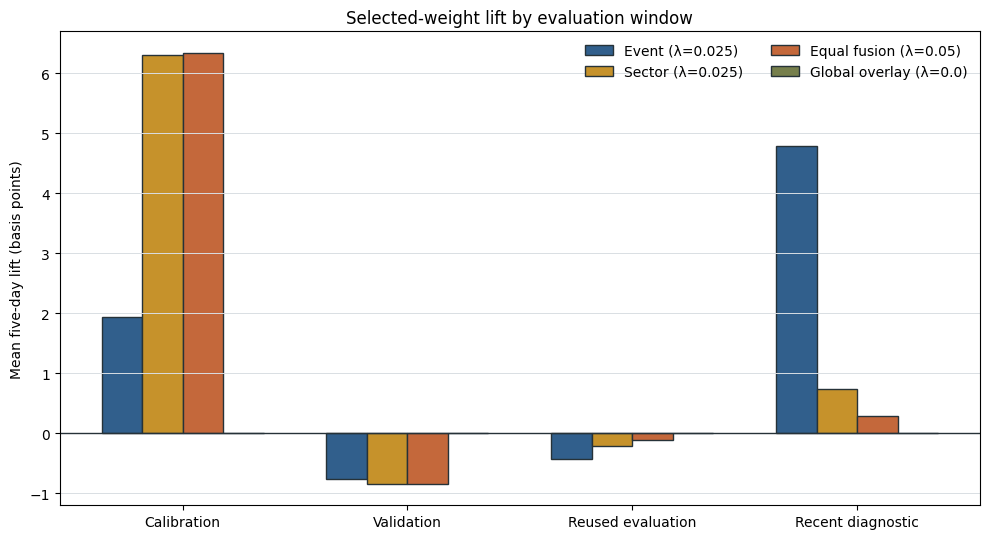

In [3]:
windows = ['calibration', 'validation', 'reused_evaluation', 'recent_diagnostic']
window_labels = ['Calibration', 'Validation', 'Reused evaluation', 'Recent diagnostic']
arms = ['event_only', 'sector_only', 'equal_fusion', 'global_overlay']
arm_labels = ['Event', 'Sector', 'Equal fusion', 'Global overlay']
palette = ['#315F8C', '#C6922B', '#C4683B', '#767F4C']
x = list(range(len(windows)))
width = 0.18
fig, ax = plt.subplots(figsize=(10, 5.5))
for index, (arm, label, color) in enumerate(zip(arms, arm_labels, palette)):
    selected = str(result['selected_weights'][arm])
    lifts = [result['evaluations'][arm][selected][window]['mean_lift'] * 10000 for window in windows]
    positions = [value + (index - 1.5) * width for value in x]
    ax.bar(positions, lifts, width=width, label=f"{label} (λ={selected})", color=color, edgecolor='#263238')
ax.axhline(0, color='#263238', linewidth=1)
ax.set_xticks(x, window_labels)
ax.set_ylabel('Mean five-day lift (basis points)')
ax.set_title('Selected-weight lift by evaluation window')
ax.grid(axis='y', color='#D9DEE3', linewidth=0.7)
ax.legend(ncol=2, frameon=False)
fig.tight_layout()
plt.show()

In [4]:
summary_rows = []
for arm in arms:
    selected = result['selected_weights'][arm]
    metrics = result['evaluations'][arm][str(selected)]
    summary_rows.append({
        'arm': arm,
        'selected_lambda': selected,
        'validation_lift_bps': round(metrics['validation']['mean_lift'] * 10000, 3),
        'reused_evaluation_lift_bps': round(metrics['reused_evaluation']['mean_lift'] * 10000, 3),
        'recent_lift_bps': round(metrics['recent_diagnostic']['mean_lift'] * 10000, 3),
        'directional_pass': result['gates'][arm]['directional_pass'],
    })
summary_rows

[{'arm': 'event_only',
  'selected_lambda': 0.025,
  'validation_lift_bps': -0.751,
  'reused_evaluation_lift_bps': -0.432,
  'recent_lift_bps': 4.791,
  'directional_pass': False},
 {'arm': 'sector_only',
  'selected_lambda': 0.025,
  'validation_lift_bps': -0.838,
  'reused_evaluation_lift_bps': -0.209,
  'recent_lift_bps': 0.736,
  'directional_pass': False},
 {'arm': 'equal_fusion',
  'selected_lambda': 0.05,
  'validation_lift_bps': -0.838,
  'reused_evaluation_lift_bps': -0.114,
  'recent_lift_bps': 0.297,
  'directional_pass': False},
 {'arm': 'global_overlay',
  'selected_lambda': 0.0,
  'validation_lift_bps': 0.0,
  'reused_evaluation_lift_bps': 0.0,
  'recent_lift_bps': 0.0,
  'directional_pass': False}]

## Takeaways

- No arm passed the frozen directional gate.
- Event and sector residuals changed very few Top3 names; observed lift was correspondingly small and unstable.
- Global risk reduction helped the latest periods only at larger weights but hurt calibration and validation, which is evidence of regime dependence rather than a usable static rule.
- The next defensible test is a preregistered forward-only regime gate, not another same-window weight search.